# Data Wrangling - Wine Quality Dataset

## Paso 1 - Carga de datos

In [1]:
import pandas as pd

df_red = pd.read_csv('Wine/winequality-red.csv', sep=';')
df_white = pd.read_csv('Wine/winequality-white.csv', sep=';')

df_red['type'] = 'red'
df_white['type'] = 'white'

df = pd.concat([df_red, df_white], ignore_index=True)

print("Shape del DataFrame:")
print(df.shape)
print("\nPrimeros registros:")
print(df.head())
print("\nRegistros por tipo:")
print(df['type'].value_counts())

Shape del DataFrame:
(6497, 13)

Primeros registros:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality type  
0     

### Conclusión Paso 1

Se cargaron los dos archivos CSV sin problema:
- winequality-red.csv: 1,599 vinos tintos
- winequality-white.csv: 4,898 vinos blancos

Total: 6,497 registros en un único DataFrame con 13 columnas (las 12 características del vino más una columna para indicar el tipo).

## Paso 2 - Inspección inicial

In [2]:
print("Tipos de datos de cada columna:")
print(df.dtypes)
print("\nEstadísticas descriptivas:")
print(df.describe())
print("\nInformación general del DataFrame:")
df.info()

Tipos de datos de cada columna:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                        str
dtype: object

Estadísticas descriptivas:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7

### Conclusión Paso 2

Tipos de datos encontrados:
- 11 columnas con números decimales (float64): acidez fija, acidez volátil, ácido cítrico, azúcar residual, cloruros, dióxido de azufre libre/total, densidad, pH, sulfatos, alcohol
- 1 columna con números enteros (int64): calidad
- 1 columna de texto (object): tipo

Lo importante:
- Alcohol: en promedio 10.49% (va de 8.0 a 14.9%)
- Calidad: en promedio 5.82 (va de 3 a 9)
- Usa 689.4 KB de memoria

No hay valores vacíos en ninguna columna, todo está completo.

## Paso 3 - Análisis de valores nulos

In [3]:
print("Valores nulos por columna:")
nulos_por_columna = df.isnull().sum()
print(nulos_por_columna)
print("\nPorcentaje de valores nulos por columna:")
total_filas = len(df)
porcentaje_nulos = (nulos_por_columna / total_filas) * 100
print(porcentaje_nulos)
print("\nResultado:")
if nulos_por_columna.sum() == 0:
    print("No hay valores nulos en ninguna columna.")
    print("No se necesita eliminar o rellenar nada.")
else:
    print(f"Se encontraron {nulos_por_columna.sum()} valores nulos.")
    columnas_con_nulos = nulos_por_columna[nulos_por_columna > 0]
    print(f"Columnas afectadas: {columnas_con_nulos.index.tolist()}")

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Porcentaje de valores nulos por columna:
fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
type                    0.0
dtype: float64

Resultado:
No hay valores nulos en ninguna columna.
No se necesita eliminar o rellenar nada.


### Conclusión Paso 3

Se revisó si hay datos faltantes. El resultado:

- 0 valores nulos en todas las 13 columnas
- 0% de datos faltantes en cada variable
- Todos los 6,497 registros están completos

No hay nada que reparar. El archivo viene limpio y listo para seguir.

## Paso 4 - Eliminación de duplicados

In [4]:
shape_original = df.shape
print("Shape antes de eliminar duplicados:")
print(f"Filas: {shape_original[0]}, Columnas: {shape_original[1]}")

duplicados_count = df.duplicated().sum()
print(f"\nDuplicados encontrados: {duplicados_count}")

df = df.drop_duplicates().reset_index(drop=True)

shape_final = df.shape
print(f"\nShape después de eliminar duplicados:")
print(f"Filas: {shape_final[0]}, Columnas: {shape_final[1]}")

filas_eliminadas = shape_original[0] - shape_final[0]
print(f"\nFilas eliminadas: {filas_eliminadas}")

Shape antes de eliminar duplicados:
Filas: 6497, Columnas: 13

Duplicados encontrados: 1177

Shape después de eliminar duplicados:
Filas: 5320, Columnas: 13

Filas eliminadas: 1177


### Conclusión Paso 4

Se encontraron 1,177 filas duplicadas (casi el 18% del total). Se eliminaron todas.

Cambios:
- De 6,497 registros bajamos a 5,320 registros únicos
- Se perdieron 1,177 filas duplicadas

Ahora el archivo no tiene repeticiones.

## Paso 5 - Corrección de tipos de datos

In [5]:
print("Tipos de datos antes:")
print(df.dtypes)

df['quality'] = df['quality'].astype('int32')
df['type'] = df['type'].astype('category')

print("\nTipos de datos después:")
print(df.dtypes)

print("\nMemoria usada después:")
print(f"Total: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

Tipos de datos antes:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                        str
dtype: object

Tipos de datos después:
fixed acidity            float64
volatile acidity         float64
citric acid              float64
residual sugar           float64
chlorides                float64
free sulfur dioxide      float64
total sulfur dioxide     float64
density                  float64
pH                       float64
sulphates                float64
alcohol                  float64
quality                    int32
type                    category
dtype: object

Memoria usada después:
Total: 483.32 KB


### Conclusión Paso 5

Se cambiaron los tipos de datos:

1. Columna `quality`: ahora es int32 (número entero)
   - Antes: float64 (número decimal)
   - Por qué: la calidad es un número sin decimales (3, 4, 5... no 3.5)

2. Columna `type`: ahora es category (categoría)
   - Antes: text (object)
   - Por qué: solo tiene 2 valores (red o white)

Esto ahorra memoria y facilita el análisis. El tipo de datos ahora coincide con lo que es realmente cada columna.

## Paso 6 - Normalización

In [6]:
print("Valores de 'alcohol' y 'density' antes de normalizar:")
print(df[['alcohol', 'density']].head(10))
print(f"\nMáximo de alcohol: {df['alcohol'].max()}")
print(f"Máximo de density: {df['density'].max()}")

df['alcohol'] = df['alcohol'] / df['alcohol'].max()
df['density'] = df['density'] / df['density'].max()

print("\nValores de 'alcohol' y 'density' después de normalizar:")
print(df[['alcohol', 'density']].head(10))
print(f"\nMáximo de alcohol: {df['alcohol'].max()}")
print(f"Máximo de density: {df['density'].max()}")
print(f"Mínimo de alcohol: {df['alcohol'].min():.4f}")
print(f"Mínimo de density: {df['density'].min():.4f}")

Valores de 'alcohol' y 'density' antes de normalizar:
   alcohol  density
0      9.4   0.9978
1      9.8   0.9968
2      9.8   0.9970
3      9.8   0.9980
4      9.4   0.9978
5      9.4   0.9964
6     10.0   0.9946
7      9.5   0.9968
8     10.5   0.9978
9      9.2   0.9959

Máximo de alcohol: 14.9
Máximo de density: 1.03898

Valores de 'alcohol' y 'density' después de normalizar:
    alcohol   density
0  0.630872  0.960365
1  0.657718  0.959402
2  0.657718  0.959595
3  0.657718  0.960557
4  0.630872  0.960365
5  0.630872  0.959017
6  0.671141  0.957285
7  0.637584  0.959402
8  0.704698  0.960365
9  0.617450  0.958536

Máximo de alcohol: 1.0
Máximo de density: 1.0
Mínimo de alcohol: 0.5369
Mínimo de density: 0.9501


### Conclusión Paso 6

La normalización consiste en convertir los números a una escala de 0 a 1. Se hace dividiendo cada valor por el máximo de su columna.

Se normalizaron dos columnas:
- alcohol: va de 8.0 a 14.9 → ahora de 0 a 1
- density: va de 0.9871 a 1.0390 → ahora de 0 a 1

Por qué se hizo:
- Estos dos valores tienen escalas muy diferentes
- Si los usamos así en un análisis, los números grandes dominan
- Ponerlos en la misma escala hace la comparación más justa

Resultado: Ambas columnas ahora están entre 0 y 1, listos para análisis.

## Paso 7 - Binning

Distribución de calidad por categorías:
quality-binned
Low        236
Medium    4075
High      1009
Name: count, dtype: int64

Muestra de datos:
    quality quality-binned
0         5         Medium
1         5         Medium
2         5         Medium
3         6         Medium
4         5         Medium
5         5         Medium
6         7           High
7         7           High
8         5         Medium
9         5         Medium
10        5         Medium
11        5         Medium
12        5         Medium
13        5         Medium
14        7           High


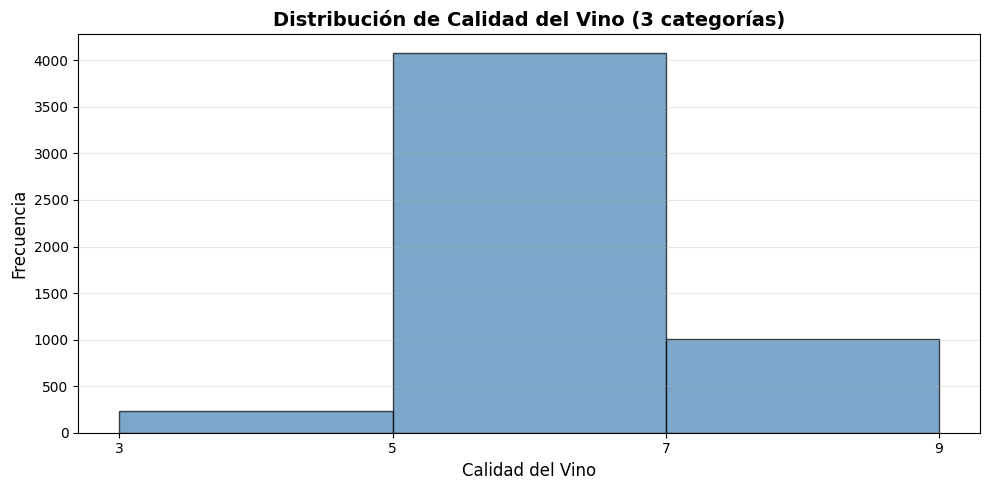


Histograma mostrado.


In [7]:
import matplotlib.pyplot as plt

bins = [2.5, 4.5, 6.5, 10]
labels = ['Low', 'Medium', 'High']

df['quality-binned'] = pd.cut(df['quality'], bins=bins, labels=labels, right=True)

print("Distribución de calidad por categorías:")
print(df['quality-binned'].value_counts().sort_index())

print("\nMuestra de datos:")
print(df[['quality', 'quality-binned']].head(15))

plt.figure(figsize=(10, 5))
plt.hist(df['quality'], bins=3, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Calidad del Vino', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Calidad del Vino (3 categorías)', fontsize=14, fontweight='bold')
plt.xticks([3, 5, 7, 9])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nHistograma mostrado.")

### Conclusión Paso 7

El binning es agrupar valores en categorías. En lugar de decir "calidad 5.3" es más fácil decir "calidad media".

Se creó una nueva columna quality-binned que agrupa así:
- Low (Baja): calidad 3-4
- Medium (Media): calidad 5-6
- High (Alta): calidad 7-9

Por qué:
- Es más fácil de entender: "vino de baja calidad" es más claro que "calidad 3.5"
- Agrupa variaciones pequeñas en categorías significativas
- Facilita ver patrones en los datos

Qué se encontró:
- La mayoría de vinos quedan en Medium
- Menos en High
- Muy pocos en Low

Resultado: Ahora tenemos ambas versiones de calidad (número exacto + categoría).

## Paso 8 - Variables Dummy

In [8]:
dummy_type = pd.get_dummies(df['type'], prefix='type', drop_first=False)

dummy_type.columns = ['type-red', 'type-white']

print("Variables dummy creadas:")
print(dummy_type.head(10))

df = pd.concat([df, dummy_type], axis=1)

df = df.drop(columns=['type'])

print("\nDataFrame final con variables dummy:")
print(df.head(10))

print("\nColumnas del DataFrame final:")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")
print("\nTipos de datos:")
print(df.dtypes)

Variables dummy creadas:
   type-red  type-white
0      True       False
1      True       False
2      True       False
3      True       False
4      True       False
5      True       False
6      True       False
7      True       False
8      True       False
9      True       False

DataFrame final con variables dummy:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.66         0.00             1.8      0.075   
5            7.9              0.60         0.06             1.6      0.069   
6            7.3              0.65         0.00             1.2      0.065   
7            7.8              0.58         0.02  

### Conclusión Paso 8

Las variables dummy convierten categorías en números (0 o 1). Se usan para que los algoritmos de análisis puedan procesar texto.

Se transformó:
- Columna original: type (con "red" o "white")
- Nuevas columnas: type-red y type-white

Cómo funciona:
- Si es vino tinto: type-red=1, type-white=0
- Si es vino blanco: type-red=0, type-white=1

Por qué se hace:
- Los algoritmos de análisis necesitan números, no texto
- Esta es la forma estándar de convertir texto a números
- Se elimina la columna original

Resultado: Ahora todo el archivo es números, listo para análisis.

## Paso 9 - Guardar dataset limpio

In [9]:
df.to_csv('clean_wine.csv', index=False, sep=';')

print("Dataset guardado en: clean_wine.csv")

print("\nShape final del DataFrame:")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\nColumnas finales:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print("\nResumen final:")
print(f"Registros únicos: {df.shape[0]}")
print(f"Total de columnas: {df.shape[1]}")
print("\nArchivo listo para análisis.")

Dataset guardado en: clean_wine.csv

Shape final del DataFrame:
Filas: 5320, Columnas: 15

Columnas finales:
 1. fixed acidity
 2. volatile acidity
 3. citric acid
 4. residual sugar
 5. chlorides
 6. free sulfur dioxide
 7. total sulfur dioxide
 8. density
 9. pH
10. sulphates
11. alcohol
12. quality
13. quality-binned
14. type-red
15. type-white

Resumen final:
Registros únicos: 5320
Total de columnas: 15

Archivo listo para análisis.


## Conclusiones Generales

### Resumen del Data Wrangling

Este notebook muestra cómo preparar datos brutos para análisis. Se partió de dos archivos CSV y se llegó a un archivo limpio y listo para usar.

**PASO 1 - Carga de datos**
- Se cargaron dos archivos: uno con vinos tintos (1,599) y otro con blancos (4,898)
- Se creó una columna para diferenciarlos
- Total: 6,497 registros con 13 columnas

**PASO 2 - Inspección inicial**
- Se revisó qué tipos de datos hay
- Se vieron promedios y rangos
- Alcohol promedio: 10.49%, Calidad: entre 3 y 9

**PASO 3 - Valores nulos**
- Se verificó si faltaban datos
- Resultado: ninguno falta, todo está completo

**PASO 4 - Duplicados**
- Se encontraron 1,177 registros repetidos
- Se eliminaron todos
- De 6,497 bajó a 5,320 registros

**PASO 5 - Tipos de datos**
- Se cambió quality a número entero (int32)
- Se cambió type a categoría
- Esto ahorra memoria

**PASO 6 - Normalización**
- Se escalaron alcohol y density a valores entre 0 y 1
- Esto evita que los números grandes dominen el análisis

**PASO 7 - Binning**
- Se agrupó calidad en 3 categorías: Low, Medium, High
- Facilita entender los datos

**PASO 8 - Variables dummy**
- Se convirtió type (red/white) a números (0 o 1)
- Ahora todo es números

**PASO 9 - Guardar**
- Se guardó el archivo limpio como clean_wine.csv
- 5,320 registros por 15 columnas

---

### Cambios en el archivo

| Aspecto | Antes | Después |
|---------|-------|---------|
| Registros | 6,497 | 5,320 |
| Columnas | 13 | 15 |
| Valores nulos | ninguno | ninguno |
| Duplicados | 1,177 | 0 |

El archivo está listo para análisis.